In [292]:
import pickle
import os
import copy
import matplotlib.pyplot as plt
import pandas as pd

In [293]:
def parse_task_by_dirname(root_path, simulation_dir):
    if 'name_format_1' in root_path:
        task_string = simulation_dir.split('_')[-1]
        task_type = task_string[:-1]
        task_seed = 0
        task_level = task_string[-1]
    
    # elif 'name_format_2' in root_path:
    else:
        task_string = simulation_dir.split('T')[-1]
        task_string_splitted = task_string.split('_')
        task_type = task_string_splitted[0]
        assert len(task_string_splitted) == 3, f'task string {task_string} is not in the correct format'
        assert task_string_splitted[1][0] == 's' and task_string_splitted[2][0] == 'l', f'task string {task_string} is not in the correct format'
        task_seed = int(task_string_splitted[1][1:])
        task_level = int(task_string_splitted[2][1:])
    # else:
    #     raise ValueError(f'root path {root_path} not supported')
    assert task_type in ['bin', 'reach','manual','follow'], f'task type {task_type} not supported'
    return task_type, task_seed, task_level

def pasrse_sim_info_by_dirname(root_path, simulation_dir):
    if 'name_format_1' in root_path:
        # example: 2025-08-16_16:43:16_ur5e4O_bin3 
        splitted_string = simulation_dir.split('_')
        timestamp = splitted_string[0] + '_' + splitted_string[1]
        robot_arms_alg = splitted_string[2]
        n_arms = 4
        robot_name, alg = robot_arms_alg.split('4')
        assert robot_name in ['ur5e','ur10e'], f'robot_name {robot_name} is not valid'
        task_parsed = parse_task_by_dirname(root_path, simulation_dir)
        task_type, task_seed, task_level = task_parsed
        
        
        # ans = timestamp, robot_name, n_arms, alg, task_type, task_seed, task_level
    else:  
    # elif 'name_format_2' in root_path:
        # example: # 2025-08-16_16:43:16_ur5e4O_bin3 
        splitted_string = simulation_dir.split('_')
        timestamp = splitted_string[0] + '_' + splitted_string[1]
        robot_name = splitted_string[3]
        n_arms = int(splitted_string[4][1:])
        alg = splitted_string[5][1:]
        task_parsed = parse_task_by_dirname(root_path, simulation_dir)
        task_type, task_seed, task_level = task_parsed

        # ans =  timestamp, robot_name, n_arms, alg, task_type, task_seed, task_level
    # else:
    #     raise ValueError(f'root path {root_path} not supported')
    
    return {'timestamp':timestamp, 'robot_name':robot_name, 'n_arms':n_arms, 'alg':alg, 'task_type':task_type, 'task_seed':task_seed, 'task_level':task_level}


In [294]:
import dataclasses

@dataclasses.dataclass
class DataSet:
    algs: list[str]
    seeds: list[int]
    tasks: list[str]
    levels: list[list[int]]


class DataSetDir:
    def __init__(self, dataset_requirements: DataSet, root_path: str):
        self.dataset_requirements = dataset_requirements
        self.root_path = root_path
        self.required_dirs = list(self.get_required())        
        self.found_dirs = self.get_found(root_path)
        
    def get_required(self):
        for alg in self.dataset_requirements.algs:
            for seed in self.dataset_requirements.seeds:
                for i, task in enumerate(self.dataset_requirements.tasks):
                    for level in self.dataset_requirements.levels[i]:
                        yield alg, seed, task, level

    def get_found(self, root_path):
        dirs = os.listdir(root_path)
        found = []
        for dir in dirs:
            parsed_dir = pasrse_sim_info_by_dirname(root_path, dir)
            alg, seed, task, level = parsed_dir['alg'], parsed_dir['task_seed'], parsed_dir['task_type'], parsed_dir['task_level']
            combo = (alg, seed, task, level) 
            found.append(combo)
        return found
    
    def get_missing(self):
        return list(set(self.required_dirs) - set(self.found_dirs))
    

   
all_algs = ['O','O-','CC','SD','SC']
all_seeds = [0,1,2]
all_tasks = ['bin','reach','follow']
all_levels = [list(range(1,7)), list(range(1,7)), list(range(1,19))]
dataset_name_to_obj = {}
dataset_name_to_obj['aug18'] = DataSet(algs=all_algs, seeds=all_seeds, tasks=all_tasks, levels=[[1,2,3,4,5],[1,2,3,4,5,6],[4,5,6,10,11,12]])
 


# Input

In [295]:
dataset = 'aug18'
root_path = '/home/dan/Desktop/data_benchmarks/name_format_2/from_cluster/require_verification/18_8/dataset1'

# Input info

In [296]:

dataset_dir = DataSetDir(dataset_name_to_obj[dataset], root_path)
n_required = len(dataset_dir.required_dirs)
n_found = len(dataset_dir.found_dirs)
if n_found != n_required:
    print(f'Warning: Found {n_found} out of {n_required} dirs')
    print(f'Missing {n_required - n_found} dirs')
    print(f'Next combinations are missing')
    for combo in dataset_dir.required_dirs:
        if combo not in dataset_dir.found_dirs:
            print(combo)
else:
    print(f'Found all {n_found} dirs')
    print(f'All {n_found} dirs are found')

df_dataset_dir = pd.DataFrame(dataset_dir.found_dirs, columns=['alg', 'seed', 'task', 'level'])
    

Missing 51 dirs
Next combinations are missing
('O', 0, 'bin', 1)
('O', 0, 'bin', 2)
('O', 0, 'bin', 3)
('O', 0, 'bin', 4)
('O', 0, 'bin', 5)
('O', 0, 'reach', 1)
('O', 0, 'reach', 2)
('O', 0, 'reach', 3)
('O', 0, 'reach', 4)
('O', 0, 'reach', 5)
('O', 0, 'reach', 6)
('O', 0, 'follow', 4)
('O', 0, 'follow', 5)
('O', 0, 'follow', 6)
('O', 0, 'follow', 10)
('O', 0, 'follow', 11)
('O', 0, 'follow', 12)
('O', 1, 'bin', 1)
('O', 1, 'bin', 2)
('O', 1, 'bin', 3)
('O', 1, 'bin', 4)
('O', 1, 'bin', 5)
('O', 1, 'reach', 1)
('O', 1, 'reach', 2)
('O', 1, 'reach', 3)
('O', 1, 'reach', 4)
('O', 1, 'reach', 5)
('O', 1, 'reach', 6)
('O', 1, 'follow', 4)
('O', 1, 'follow', 5)
('O', 1, 'follow', 6)
('O', 1, 'follow', 10)
('O', 1, 'follow', 11)
('O', 1, 'follow', 12)
('O', 2, 'bin', 1)
('O', 2, 'bin', 2)
('O', 2, 'bin', 3)
('O', 2, 'bin', 4)
('O', 2, 'bin', 5)
('O', 2, 'reach', 1)
('O', 2, 'reach', 2)
('O', 2, 'reach', 3)
('O', 2, 'reach', 4)
('O', 2, 'reach', 5)
('O', 2, 'reach', 6)
('O', 2, 'follow', 4)

In [297]:
df_dataset_dir

,alg,seed,task,level
0,SD,0,bin,1
1,SC,2,bin,5
2,SD,2,reach,6
3,CC,0,follow,12
4,SC,0,bin,3
...,...,...,...,...
199,SC,1,reach,2
200,SC,1,follow,12
201,SD,2,bin,5
202,SD,1,reach,5


In [298]:

# path = '/home/dan/mr_mpc_logs/2025-08-12_18:56:44_ur5e4O_bin1/stats.pkl' # './out/2025-08-09_11:55:02/stats.pkl'
# root_path = '/home/dan/Desktop/data_benchmarks/name_format_1/task_seed_0/selected_from_cluster'
# root_path = '/home/dan/mr_mpc_logs/benchmarks_bin_test_aug17'

stat_file_name = 'stats.pkl'

simulation_dirs = os.listdir(root_path)

sim_names = []
sim_stats = []
print(f'Loading {len(simulation_dirs)} simulations pickle files...')
for i, sim_dir in enumerate(simulation_dirs):
    print(f'    Loading Simulation {i+1} out of {len(simulation_dirs)}')
    print(f'    Loading Simulation dir: {sim_dir}')
    print('-'*100)
    stats_path = os.path.join(root_path, sim_dir, stat_file_name)
    if os.path.exists(stats_path):
        with open(stats_path, 'rb') as f:
            stats = pickle.load(f)
            sim_names.append(sim_dir)
            sim_stats.append(stats)
        # print(stats)
    else:
        print(f'Stats file not found for simulation {sim_dir}')
        print('-'*100)





Loading 204 simulations pickle files...
    Loading Simulation 1 out of 204
    Loading Simulation dir: 2025-08-18_12:24:08_R_ur5e_N4_ASD_Tbin_s0_l1
----------------------------------------------------------------------------------------------------
    Loading Simulation 2 out of 204
    Loading Simulation dir: 2025-08-18_11:42:21_R_ur5e_N4_ASC_Tbin_s2_l5
----------------------------------------------------------------------------------------------------
    Loading Simulation 3 out of 204
    Loading Simulation dir: 2025-08-18_13:55:42_R_ur5e_N4_ASD_Treach_s2_l6
----------------------------------------------------------------------------------------------------
    Loading Simulation 4 out of 204
    Loading Simulation dir: 2025-08-18_16:52:51_R_ur5e_N4_ACC_Tfollow_s0_l12
----------------------------------------------------------------------------------------------------
    Loading Simulation 5 out of 204
    Loading Simulation dir: 2025-08-18_11:34:17_R_ur5e_N4_ASC_Tbin_s0_l3
-----

In [299]:
print(f'stat manager names:')
sim_stats[0].keys()


stat manager names:


dict_keys(['task_stats', 'agent_0', 'agent_1', 'agent_2', 'agent_3'])

In [300]:
def get_statman_keys(statman_data):
    return stats[statman_data].keys()

def get_stat_keys(statman_data, stat_name):
    return statman_data[stat_name].keys()

def get_stat_vals(statman_data, stat_name):
    return statman_data[stat_name]

def get_sim_keys(sim_name, sim_stats):
    for sm_name in sim_stats.keys(): # statman name
        for stat_name in sim_stats[sm_name].keys():
            print(f'simname: {sim_name}, sman: {sm_name}, s:{stat_name}')


Sim info

In [301]:

for sim_name, sim_stat in zip(sim_names, sim_stats):
    print(f'Sim info:')
    get_sim_keys(sim_name, sim_stat)
    print('')

    

Sim info:
simname: 2025-08-18_12:24:08_R_ur5e_N4_ASD_Tbin_s0_l1, sman: task_stats, s:arm_err
simname: 2025-08-18_12:24:08_R_ur5e_N4_ASD_Tbin_s0_l1, sman: task_stats, s:arm_picks
simname: 2025-08-18_12:24:08_R_ur5e_N4_ASD_Tbin_s0_l1, sman: task_stats, s:arm_drops
simname: 2025-08-18_12:24:08_R_ur5e_N4_ASD_Tbin_s0_l1, sman: agent_0, s:env_cols
simname: 2025-08-18_12:24:08_R_ur5e_N4_ASD_Tbin_s0_l1, sman: agent_0, s:link_target_poses
simname: 2025-08-18_12:24:08_R_ur5e_N4_ASD_Tbin_s0_l1, sman: agent_0, s:arm_cols
simname: 2025-08-18_12:24:08_R_ur5e_N4_ASD_Tbin_s0_l1, sman: agent_0, s:total_planning_time
simname: 2025-08-18_12:24:08_R_ur5e_N4_ASD_Tbin_s0_l1, sman: agent_0, s:spheres
simname: 2025-08-18_12:24:08_R_ur5e_N4_ASD_Tbin_s0_l1, sman: agent_1, s:env_cols
simname: 2025-08-18_12:24:08_R_ur5e_N4_ASD_Tbin_s0_l1, sman: agent_1, s:link_target_poses
simname: 2025-08-18_12:24:08_R_ur5e_N4_ASD_Tbin_s0_l1, sman: agent_1, s:arm_cols
simname: 2025-08-18_12:24:08_R_ur5e_N4_ASD_Tbin_s0_l1, sman: 

In [302]:
# sim_stats[0]['task_stats'].keys()
# for stat_name in sim_stats[0]['task_stats'].keys():
#     print(f'stat name: {stat_name}')
#     print(sim_stats[0]['task_stats'][stat_name])
#     print('-'*100)

def find_task_statman_name(stats):
    for statman_name in stats.keys():
        if 'agent' not in statman_name:
            return statman_name
    return None

def find_agent_statman_names(stats):
    agent_statman_names = []
    for statman_name in stats.keys():
        if 'agent' in statman_name:
            agent_statman_names.append(statman_name)
    return agent_statman_names

def get_stat_from_statman(statman, stat_name, keys='all'):
    stat = statman[stat_name]
    if keys == 'all':
        return stat
    
    stat_filtered = []
    for stat_keys,stat_vals in stat.items():
        filtered_entry_keys = {}
        for key in keys:
            if key in stat_keys:
                filtered_entry_keys[key] = stat_vals[key]
                filtered_entry_vals = stat_vals
                stat_filtered.append((filtered_entry_keys,filtered_entry_vals))
    return stat_filtered
    
    
def split_task_to_k_v(stat):
    k = []
    v = []
    for item in stat:
        k.append(item[0])
        v.append(item[1])
    return k, v

def parse_task_by_dirname(root_path, simulation_dir):
    if 'name_format_1' in root_path:
        task_string = simulation_dir.split('_')[-1]
        task_type = task_string[:-1]
        task_seed = 0
        task_level = task_string[-1]
    
    # elif 'name_format_2' in root_path:
    else:
        task_string = simulation_dir.split('T')[-1]
        task_string_splitted = task_string.split('_')
        task_type = task_string_splitted[0]
        assert len(task_string_splitted) == 3, f'task string {task_string} is not in the correct format'
        assert task_string_splitted[1][0] == 's' and task_string_splitted[2][0] == 'l', f'task string {task_string} is not in the correct format'
        task_seed = int(task_string_splitted[1][1:])
        task_level = int(task_string_splitted[2][1:])
    # else:
    #     raise ValueError(f'root path {root_path} not supported')
    assert task_type in ['bin', 'reach','manual','follow'], f'task type {task_type} not supported'
    return task_type, task_seed, task_level

    

def pasrse_sim_info_by_dirname(root_path, simulation_dir):
    if 'name_format_1' in root_path:
        # example: 2025-08-16_16:43:16_ur5e4O_bin3 
        splitted_string = simulation_dir.split('_')
        timestamp = splitted_string[0] + '_' + splitted_string[1]
        robot_arms_alg = splitted_string[2]
        n_arms = 4
        robot_name, alg = robot_arms_alg.split('4')
        assert robot_name in ['ur5e','ur10e'], f'robot_name {robot_name} is not valid'
        task_parsed = parse_task_by_dirname(root_path, simulation_dir)
        task_type, task_seed, task_level = task_parsed
        
        
        # ans = timestamp, robot_name, n_arms, alg, task_type, task_seed, task_level
    else:  
    # elif 'name_format_2' in root_path:
        # example: # 2025-08-16_16:43:16_ur5e4O_bin3 
        splitted_string = simulation_dir.split('_')
        timestamp = splitted_string[0] + '_' + splitted_string[1]
        robot_name = splitted_string[3]
        n_arms = int(splitted_string[4][1:])
        alg = splitted_string[5][1:]
        task_parsed = parse_task_by_dirname(root_path, simulation_dir)
        task_type, task_seed, task_level = task_parsed

        # ans =  timestamp, robot_name, n_arms, alg, task_type, task_seed, task_level
    # else:
    #     raise ValueError(f'root path {root_path} not supported')
    
    return {'timestamp':timestamp, 'robot_name':robot_name, 'n_arms':n_arms, 'alg':alg, 'task_type':task_type, 'task_seed':task_seed, 'task_level':task_level}


class SimStats:
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        self.task_stats_parsed = []
        self.meta_data = meta_data
        self.sim_stats = sim_stats
        self.task_stats = sim_stats['task_stats']
        agents_statman_names = [x for x in sim_stats.keys() if 'agent' in x]
        agents_statman_names.sort(key=lambda x: int(x.split('_')[-1])) # sort by agent index
        self.agent_stats = []
        for statman_name in agents_statman_names:
            self.agent_stats.append(sim_stats[statman_name])
        
        
        self.parsed = self.parse()
        if len(sort_by) > 0:
            self.parsed = sorted(self.parsed, key=lambda x: x[sort_by[0]])

        self._make_agents_dfs()
        


    def _make_agents_dfs(self):
        agents_tmp_lists = []
        for agent_idx in range(self.get_n_agents()):
            columns = []
            

            # find all columns
            for stat_name in self.agent_stats[agent_idx].keys():
                if stat_name not in columns:
                    columns.append(stat_name)    
                stat = self.agent_stats[agent_idx][stat_name]
                for kv in stat:
                    for k in kv[0]:
                        if k not in columns:
                            columns.append(k)

            # fill in the data  
            rows = []
            colname_to_index = {col:i for i, col in enumerate(columns)}
            for stat_name in self.agent_stats[agent_idx].keys():
                stat = self.agent_stats[agent_idx][stat_name]
                stat_col_idx = colname_to_index[stat_name]
                for kv in stat: # for each row in the stat
                    new_data_row = [None for _ in range(len(columns))]
                    val = kv[1]
                    if stat_name == 'env_cols':
                        try:
                            val = val.cpu().item()
                        except:
                            try:
                                val = val.item()
                            except:
                                val = val
                    new_data_row[stat_col_idx] = val
                    for k in kv[0]:
                        new_data_row[colname_to_index[k]] = kv[0][k]
                    rows.append(new_data_row)
            
            # save the agents raw data for df
            agents_tmp_lists.append((columns, rows))
        
        # make dfs
        self._agents_dfs = []
        for agent_idx in range(self.get_n_agents()):
            agent_df =  pd.DataFrame(columns=agents_tmp_lists[agent_idx][0], data=agents_tmp_lists[agent_idx][1])
            self._agents_dfs.append(agent_df)
            
                    

    def get_agents_dfs(self):
        return self._agents_dfs
        
    def parse(self):
        parsed = []
        # print(f'parsing sim')
        for statman_name in self.sim_stats.keys():
            # print(f'\nparsing stat-manager: {statman_name}...')
            for stat_name in self.sim_stats[statman_name].keys():
                # print(f'    parsing stat: {stat_name}...')
                stat_vals = self.sim_stats[statman_name][stat_name]
                # stat_entries = []
                for stat_kv in stat_vals:        
                    # stat entry (unique key)
                    s_entry = {}
                    s_entry[f'{statman_name}_{stat_name}'] = stat_kv[1]
                    for k_key, v_key in stat_kv[0].items():
                        s_entry[k_key] = v_key
                    # stat_entries.append(s_entry)
                    parsed.append(s_entry)
                # stat_entries.append(s_entry)
        # print(f'parsing finished, parsed {len(parsed)} entries')
        return parsed
        
    def __repr__(self):
        out = '\n'
        for k,v in self.meta_data.items():
            out += f'{k}: {v}\n'
        return out
        
    def check_necessary_key(self, entry:dict,key:str):
        for k_entry in entry.keys():
            if key in k_entry:
                return True # found the key substring

        return False
    
    def set_planning_times(self, agents_planning_times, agents_clocktimes, agents_physics_times, agents_n_steps):
        # print(f'agents_planning_times: {agents_planning_times}')
        # print(f'agents_clocktimes: {agents_clocktimes}')
        # print(f'agents_physics_times: {agents_physics_times}')
        # print(f'agents_n_steps: {agents_n_steps}')
        
        self.agents_planning_times = agents_planning_times # total time spent in planning
        self.agents_clocktimes = agents_clocktimes # total wall time (system time) simualation + planning (should be ~same for all agents in the same simulation)
        self.agents_physics_times = agents_physics_times # total physics time simulation (should be same for all agents in the same simulation)
        self.agents_n_steps = agents_n_steps # total number of steps (should be same for all agents in the same simulation)
        self.planning_time_per_step =  [agents_planning_times[i] / agents_n_steps[i] for i in range(len(agents_planning_times))]
        # self.planning_time_per_step =  [agents_planning_times[i] / agents_n_steps[i] for i in range(len(agents_planning_times))]
        n_agents = len(agents_planning_times)
        self.mean_agent_planning_time = sum(agents_planning_times) / n_agents 
        self.mean_planning_time_per_step = sum(self.planning_time_per_step) / n_agents # normalized mean planning time per step, so we can compare between simulations in different number of steps
        
    def get_n_agents(self):
        centralized = self.is_centralized()
        n_agents = 1 if centralized else self.meta_data['n_arms']
        return n_agents
    
    def is_centralized(self):
        alg = self.meta_data['alg']
        centralized = alg not in ['O', 'O-', 'SD']
        return centralized
    
    
    
    def get_n_arms(self):
        return self.meta_data['n_arms']

    def make_task_df(self):
        
        columns = []
        rows = []
        reverse_col_name_to_index = {}

        # find all columns
        for entry in self.task_stats_parsed:
            for k,v in entry.items():
                if k not in columns:
                    columns.append(k)
                    reverse_col_name_to_index[k] = len(columns) - 1

        # fill in the data
        for entry in self.task_stats_parsed:
            new_data_row = [None for _ in range(len(columns))]
            for k,v in entry.items():
                new_data_row[reverse_col_name_to_index[k]] = v
            rows.append(new_data_row)

        # rows.append(entry)
        task_df = pd.DataFrame(rows, columns=columns)
        
        # remove duplicates
        task_df = task_df.drop_duplicates()
        
        return task_df
    
    
    
class ReachSimStats(SimStats):
    
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        super().__init__(meta_data, sim_stats, sort_by)
        self.parsed_task_stats = self.parse_task_stats()
        self.task_df = self.make_task_df()
        
    def parse_task_stats(self):
        self.n_arms = self.meta_data['n_arms']
        tmp_reached_by_t = [0 for _ in range(self.n_arms)]
        tmp_changed_by_t = [0 for _ in range(self.n_arms)]
        
        sorted_parsed = sorted(self.parsed, key=lambda x: x['w_step'])
        # print(f'len(sorted_parsed): {len(sorted_parsed)}')
        for entry in sorted_parsed:
            
            if not (self.check_necessary_key(entry,'task_stats_arm_reached') or self.check_necessary_key(entry,'task_stats_arm_changed')):
                continue # not a task related entry
            
            arm_stats_entry = {}
            # entry_keys = entry.keys()

            

            for k in entry.keys():
                if k == 'task_stats_arm_reached':
                    for arm_idx in entry[k]:
                        tmp_reached_by_t[arm_idx] += 1
                
                if k == 'task_stats_arm_changed':
                    for arm_idx in entry[k]:
                        tmp_changed_by_t[arm_idx] += 1
                
            arm_stats_entry['w_step'] = entry['w_step']
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_reached'] = tmp_reached_by_t[arm_idx]
            
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_changed'] = tmp_changed_by_t[arm_idx]
        
            self.task_stats_parsed.append(arm_stats_entry)
        return self.task_stats_parsed
    
class BinSimStats(SimStats):
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        super().__init__(meta_data, sim_stats, sort_by)
        self.parsed_task_stats = self.parse_task_stats()
        self.task_df = self.make_task_df()

    def parse_task_stats(self):
        self.n_arms = self.meta_data['n_arms']
        
        tmp_picks_by_t = [0 for _ in range(self.n_arms)]
        tmp_drops_by_t = [0 for _ in range(self.n_arms)]
        
        sorted_parsed = sorted(self.parsed, key=lambda x: x['w_step'])
        for entry in sorted_parsed:
            arm_stats_entry = {}
            
            if not (self.check_necessary_key(entry,'task_stats_arm_picks') or self.check_necessary_key(entry,'task_stats_arm_drops') or self.check_necessary_key(entry,'task_stats_arm_err')):
                continue # not a task related entry
                
            for k in entry.keys():

                if k == 'task_stats_arm_picks':
                    for arm_idx in entry[k]:
                        tmp_picks_by_t[arm_idx] += 1
                
                if k == 'task_stats_arm_drops':
                    for arm_idx in entry[k]:
                        tmp_drops_by_t[arm_idx] += 1


            arm_stats_entry['w_step'] = entry['w_step']
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_picks'] = tmp_picks_by_t[arm_idx]
            
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_drops'] = tmp_drops_by_t[arm_idx]
                        
            self.task_stats_parsed.append(arm_stats_entry)
        return self.task_stats_parsed
    
class FollowSimStats(SimStats):
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        super().__init__(meta_data, sim_stats, sort_by)
        self.parsed_task_stats = self.parse_task_stats()
        self.task_df = self.make_task_df()
        
    def parse_task_stats(self):
        self.n_arms = self.meta_data['n_arms']
        self.task_stats_parsed = []
        sorted_parsed = sorted(self.parsed, key=lambda x: x['w_step'])
        for entry in sorted_parsed:
            arm_stats_entry = {}
            
            if not self.check_necessary_key(entry,'task_stats_arm_err'):
                continue # not a task related entry
                
            arm_stats_entry['w_step'] = entry['w_step']
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_err'] = entry[f'task_stats_arm_err'][arm_idx]
                
            self.task_stats_parsed.append(arm_stats_entry)
        return self.task_stats_parsed
    
 


# Parse all sims


In [303]:
reach_sims = []
bin_sims = []
follow_sims = []

for i, this_sim_stats in enumerate(sim_stats):
    meta_data = pasrse_sim_info_by_dirname(root_path, sim_names[i])
    # print(meta_data["task_type"])
    if meta_data['task_type'] == 'reach':
        reach_sims.append(ReachSimStats(meta_data, this_sim_stats))
    elif meta_data['task_type'] == 'bin':
        try:
            bin_sims.append(BinSimStats(meta_data, this_sim_stats))
        except Exception as e:
            print(f'Error parsing bin sim stats: {e}')
            print(f'Meta data: {meta_data}')
            print(f'This sim stats: {this_sim_stats}')
            print('-'*100)
            continue
    elif meta_data['task_type'] == 'follow':
        follow_sims.append(FollowSimStats(meta_data, this_sim_stats))




## Examples (optional)

### Agent df

In [304]:
# head
agent_df_example = reach_sims[0].get_agents_dfs()[0]
agent_df_example.head()

,env_cols,tsys,tphysics,w_step,a_step,link_target_poses,arm_cols,total_planning_time,spheres
0,False,1.755515e+09,0.350000,0,1,None,None,NaN,None
1,False,1.755515e+09,0.366667,1,2,None,None,NaN,None
2,False,1.755515e+09,0.366667,2,3,None,None,NaN,None
3,False,1.755515e+09,0.383333,3,4,None,None,NaN,None
4,False,1.755515e+09,0.383333,4,5,None,None,NaN,None


In [305]:
# tail
agent_df_example.tail()

,env_cols,tsys,tphysics,w_step,a_step,link_target_poses,arm_cols,total_planning_time,spheres
2054,None,1.755515e+09,4.183334,459,460,None,None,NaN,"[[tensor(0.5000, device='cuda:0'), tensor(0.50..."
2055,None,1.755515e+09,4.250000,468,469,None,None,NaN,"[[tensor(0.5000, device='cuda:0'), tensor(0.50..."
2056,None,1.755515e+09,4.333334,477,478,None,None,NaN,"[[tensor(0.5000, device='cuda:0'), tensor(0.50..."
2057,None,1.755515e+09,4.400000,486,487,None,None,NaN,"[[tensor(0.5000, device='cuda:0'), tensor(0.50..."
2058,None,1.755515e+09,4.483334,495,496,None,None,NaN,"[[tensor(0.5000, device='cuda:0'), tensor(0.50..."


In [306]:
agent_df_example.describe()

,tsys,tphysics,w_step,a_step,total_planning_time
count,2.059000e+03,2059.000000,2059.000000,2059.000000,501.000000
mean,1.755515e+09,2.437939,250.053424,251.053424,10.881795
std,7.137903e+01,1.205131,144.614823,144.614823,6.112003
min,1.755515e+09,0.350000,0.000000,1.000000,0.035836
25%,1.755515e+09,1.400000,125.000000,126.000000,5.750884
50%,1.755515e+09,2.433333,250.000000,251.000000,11.273014
75%,1.755515e+09,3.483334,375.000000,376.000000,16.158943
max,1.755515e+09,4.516667,500.000000,501.000000,20.919445


### Bin task df

In [307]:
found = False
try:
    df = bin_sims[0].task_df
    found = True
except Exception as e:
    failure_message = ''
    if not len(bin_sims):
        failure_message = 'bin_sims is empty'
    else:
        failure_message = f'bin_sims[0].task_df is not available: {e}'
        
(df.tail() if found else f'{failure_message}')



,w_step,arm_0_total_picks,arm_1_total_picks,arm_2_total_picks,arm_3_total_picks,arm_0_total_drops,arm_1_total_drops,arm_2_total_drops,arm_3_total_drops
1485,496,2,3,1,0,4,1,0,0
1488,497,2,3,1,0,4,1,0,0
1491,498,2,3,1,0,4,1,0,0
1494,499,2,3,1,0,4,1,0,0
1497,500,2,3,1,0,4,1,0,0


In [308]:
df.describe()

,w_step,arm_0_total_picks,arm_1_total_picks,arm_2_total_picks,arm_3_total_picks,arm_0_total_drops,arm_1_total_drops,arm_2_total_drops,arm_3_total_drops
count,511.000000,511.000000,511.000000,511.000000,511.0,511.000000,511.000000,511.0,511.0
mean,251.471624,1.082192,1.281800,0.373777,0.0,1.418787,0.371820,0.0,0.0
std,144.645566,0.435097,0.926114,0.484280,0.0,1.117051,0.483764,0.0,0.0
min,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0
25%,127.500000,1.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0
50%,251.000000,1.000000,2.000000,0.000000,0.0,2.000000,0.000000,0.0,0.0
75%,376.500000,1.000000,2.000000,1.000000,0.0,2.000000,1.000000,0.0,0.0
max,500.000000,2.000000,3.000000,1.000000,0.0,4.000000,1.000000,0.0,0.0


### Reach task df

In [309]:
found = False
try:
    df = reach_sims[0].task_df
    found = True
except Exception as e:
    failure_message = ''
    if not len(bin_sims):
        failure_message = 'reach_sims is empty'
    else:
        failure_message = f'refollow_simsach_sims[0].task_df is not available: {e}'
        
(df.tail() if found else f'{failure_message}')


,w_step,arm_0_total_reached,arm_1_total_reached,arm_2_total_reached,arm_3_total_reached,arm_0_total_changed,arm_1_total_changed,arm_2_total_changed,arm_3_total_changed
990,496,2,10,0,1,5,11,4,4
992,497,2,10,0,1,5,11,4,4
994,498,2,10,0,1,5,11,4,4
996,499,2,10,0,1,5,11,4,4
998,500,2,10,0,1,5,11,4,4


In [310]:
df.describe()

,w_step,arm_0_total_reached,arm_1_total_reached,arm_2_total_reached,arm_3_total_reached,arm_0_total_changed,arm_1_total_changed,arm_2_total_changed,arm_3_total_changed
count,512.000000,512.000000,512.000000,512.0,512.000000,512.000000,512.000000,512.00000,512.000000
mean,251.714844,1.179688,3.605469,0.0,0.449219,2.345703,4.394531,1.62500,1.957031
std,143.806515,0.952357,3.423273,0.0,0.497901,1.686722,3.691187,1.20176,1.498241
min,1.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.00000,0.000000
25%,128.750000,0.000000,0.000000,0.0,0.000000,1.000000,1.000000,1.00000,1.000000
50%,251.500000,2.000000,3.000000,0.0,0.000000,3.000000,4.000000,2.00000,2.000000
75%,375.250000,2.000000,7.000000,0.0,1.000000,4.000000,8.000000,3.00000,3.000000
max,500.000000,2.000000,10.000000,0.0,1.000000,5.000000,11.000000,4.00000,4.000000


### Follow task df

In [311]:
found = False
try:
    df = follow_sims[0].task_df
    found = True
except Exception as e:
    failure_message = ''
    if not len(bin_sims):
        failure_message = 'follow_sims follow_simsis empty'
    else:
        failure_message = f'follow_sims[0].task_df is not available: {e}'
        
(df.tail() if found else f'{failure_message}')


,w_step,arm_0_err,arm_1_err,arm_2_err,arm_3_err
495,496,"(20.510049150830646, 97.73769865437365)","(15.103378858774148, 85.96281877793845)","(16.013987502147323, 81.42734293292187)","(13.477496442727864, 81.14395457854184)"
496,497,"(20.507722207250456, 98.04580542242606)","(15.107381921692722, 86.36723663640181)","(16.01411397945738, 81.3917400938753)","(13.478009501337022, 81.57048516738334)"
497,498,"(20.646696705607855, 98.04580542242606)","(15.21149790399489, 86.36723663640181)","(16.1417853510368, 81.3917400938753)","(13.575299566737565, 81.57048516738334)"
498,499,"(20.64648059239721, 98.10920982976475)","(15.21014299252352, 86.32003585819254)","(16.14216164389034, 81.5689219814016)","(13.574765477419739, 81.53676054717728)"
499,500,"(20.78595038923837, 98.10920982976475)","(15.315612213449356, 86.32003585819254)","(16.26957670638068, 81.5689219814016)","(13.670126471915562, 81.53676054717728)"


In [312]:
df.describe()

,w_step
count,500.000000
mean,250.500000
std,144.481833
min,1.000000
25%,125.750000
50%,250.500000
75%,375.250000
max,500.000000


# Statistics

#### Helpers

In [313]:
def parsing_summary(successfull_parsing, unsuccessfull_parsing):
    print(f'parsing summary:')
    print(f'successfull_parsing: {len(successfull_parsing)}')
    print(f'unsuccessfull_parsing: {len(unsuccessfull_parsing)}')
    print(f'to view errors, see unsuccessfull_parsing[i][1] for error message')



## 1. Planning times and control frequencies

In [314]:
all_sims = bin_sims + reach_sims + follow_sims

successfull_parsing = []
unsuccessfull_parsing = []

for sim_idx, sim in enumerate(all_sims):
    try:    
        # print(f'\n\n\nsim_idx: {sim_idx}, alg: {sim.meta_data["alg"]}\n\n\n')
        n_arms = sim.meta_data['n_arms']
        n_agents = sim.get_n_agents()
        agent_to_final_planning_time = [0] * n_agents
        # agent_entries = [[] for _ in range(n_agents)]
        min_wstep_entry, min_wstep = [{} for _ in range(n_agents)], [100000] * n_agents
        max_wstep_entry, max_wstep  = [{} for _ in range(n_agents)], [-1] * n_agents
        for i in range(len(sim.parsed)):
            data_entry = sim.parsed[i]
            for a_idx in range(n_agents):
                if 'tsys' in data_entry:
                    pass
                    # print(f'debug:entry {i} a{a_idx} {data_entry["tsys"]}')
                a_key_total_planning_time = f'agent_{a_idx}_total_planning_time'
                if a_key_total_planning_time in data_entry:
                    if data_entry['w_step'] < min_wstep[a_idx]:
                        min_wstep_entry[a_idx] = copy.deepcopy(data_entry)
                        min_wstep[a_idx] = data_entry['w_step']
                    if data_entry['w_step'] > max_wstep[a_idx]:
                        max_wstep_entry[a_idx] = copy.deepcopy(data_entry)
                        max_wstep[a_idx] = data_entry['w_step']

        agents_planning_times = [0] * n_agents
        agents_clocktimes = [0] * n_agents
        agents_physics_times = [0] * n_agents
        agents_n_steps = [0] * n_agents
        
        for a_idx in range(n_agents): 
            if max_wstep[a_idx] <= 0:
                raise Exception(f'agent {a_idx} has no planning time')
        
        
        #print(f'all_agents_have_planning_time: {all_agents_have_planning_time}')
        for a_idx in range(n_agents):
            a_key_total_planning_time = f'agent_{a_idx}_total_planning_time'   
            agents_planning_times[a_idx] = max_wstep_entry[a_idx][a_key_total_planning_time]
            agents_n_steps[a_idx] = max_wstep[a_idx] # if not working try w_step
            agents_clocktimes[a_idx] = max_wstep_entry[a_idx]['tsys'] - min_wstep_entry[a_idx]['tsys']
            agents_physics_times[a_idx] = max_wstep_entry[a_idx]['tphysics'] - min_wstep_entry[a_idx]['tphysics']
        all_sims[sim_idx].set_planning_times(agents_planning_times, agents_clocktimes, agents_physics_times, agents_n_steps)
    
        successfull_parsing.append(sim)
    except Exception as e:
        unsuccessfull_parsing.append((sim,e))
        # print('agent', a_idx, data_entry[a_key_total_planning_time])
                
parsing_summary(successfull_parsing, unsuccessfull_parsing)
    

parsing summary:
successfull_parsing: 200
unsuccessfull_parsing: 4
to view errors, see unsuccessfull_parsing[i][1] for error message


### a. planning time per step, by alg

### definitions:
1. V_moa - the variable V, mean of all agents
2. V_moaw - the variable V, V_moa and also over all wsteps (avg per agent per step)
2. wsteps[unitless] - total number of "world" (the name of simulation environment in isaac sim) steps (total simulation steps)
3. tplanning_moan[sec] - mean of all agents planning time (avg per agent per step) - 
4. ctrl_freq_moan[hz] - mean of all agents control frequency (avg per agent per step, ctrl freq in hz. 1/tplanning_moan)
5. tphysics[sec] - total simulated physics time (wsteps x physics dt)
6. tsys[sec] - total real tiem (simualtion took), computer's system ('wall') time


In [315]:
# sim_stats[0]['task_stats'].keys()
# for stat_name in sim_stats[0]['task_stats'].keys():
#     print(f'stat name: {stat_name}')
#     print(sim_stats[0]['task_stats'][stat_name])
#     print('-'*100)

def find_task_statman_name(stats):
    for statman_name in stats.keys():
        if 'agent' not in statman_name:
            return statman_name
    return None

def find_agent_statman_names(stats):
    agent_statman_names = []
    for statman_name in stats.keys():
        if 'agent' in statman_name:
            agent_statman_names.append(statman_name)
    return agent_statman_names

def get_stat_from_statman(statman, stat_name, keys='all'):
    stat = statman[stat_name]
    if keys == 'all':
        return stat
    
    stat_filtered = []
    for stat_keys,stat_vals in stat.items():
        filtered_entry_keys = {}
        for key in keys:
            if key in stat_keys:
                filtered_entry_keys[key] = stat_vals[key]
                filtered_entry_vals = stat_vals
                stat_filtered.append((filtered_entry_keys,filtered_entry_vals))
    return stat_filtered
    
    
def split_task_to_k_v(stat):
    k = []
    v = []
    for item in stat:
        k.append(item[0])
        v.append(item[1])
    return k, v



    



class SimStats:
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        self.task_stats_parsed = []
        self.meta_data = meta_data
        self.sim_stats = sim_stats
        self.task_stats = sim_stats['task_stats']
        agents_statman_names = [x for x in sim_stats.keys() if 'agent' in x]
        agents_statman_names.sort(key=lambda x: int(x.split('_')[-1])) # sort by agent index
        self.agent_stats = []
        for statman_name in agents_statman_names:
            self.agent_stats.append(sim_stats[statman_name])
        
        
        self.parsed = self.parse()
        if len(sort_by) > 0:
            self.parsed = sorted(self.parsed, key=lambda x: x[sort_by[0]])

        self._make_agents_dfs()
        


    def _make_agents_dfs(self):
        agents_tmp_lists = []
        for agent_idx in range(self.get_n_agents()):
            columns = []
            

            # find all columns
            for stat_name in self.agent_stats[agent_idx].keys():
                if stat_name not in columns:
                    columns.append(stat_name)    
                stat = self.agent_stats[agent_idx][stat_name]
                for kv in stat:
                    for k in kv[0]:
                        if k not in columns:
                            columns.append(k)

            # fill in the data  
            rows = []
            colname_to_index = {col:i for i, col in enumerate(columns)}
            for stat_name in self.agent_stats[agent_idx].keys():
                stat = self.agent_stats[agent_idx][stat_name]
                stat_col_idx = colname_to_index[stat_name]
                for kv in stat: # for each row in the stat
                    new_data_row = [None for _ in range(len(columns))]
                    val = kv[1]
                    if stat_name == 'env_cols':
                        try:
                            val = val.cpu().item()
                        except:
                            try:
                                val = val.item()
                            except:
                                val = val
                    new_data_row[stat_col_idx] = val
                    for k in kv[0]:
                        new_data_row[colname_to_index[k]] = kv[0][k]
                    rows.append(new_data_row)
            
            # save the agents raw data for df
            agents_tmp_lists.append((columns, rows))
        
        # make dfs
        self._agents_dfs = []
        for agent_idx in range(self.get_n_agents()):
            agent_df =  pd.DataFrame(columns=agents_tmp_lists[agent_idx][0], data=agents_tmp_lists[agent_idx][1])
            self._agents_dfs.append(agent_df)
            
                    

    def get_agents_dfs(self):
        return self._agents_dfs
        
    def parse(self):
        parsed = []
        # print(f'parsing sim')
        for statman_name in self.sim_stats.keys():
            # print(f'\nparsing stat-manager: {statman_name}...')
            for stat_name in self.sim_stats[statman_name].keys():
                # print(f'    parsing stat: {stat_name}...')
                stat_vals = self.sim_stats[statman_name][stat_name]
                # stat_entries = []
                for stat_kv in stat_vals:        
                    # stat entry (unique key)
                    s_entry = {}
                    s_entry[f'{statman_name}_{stat_name}'] = stat_kv[1]
                    for k_key, v_key in stat_kv[0].items():
                        s_entry[k_key] = v_key
                    # stat_entries.append(s_entry)
                    parsed.append(s_entry)
                # stat_entries.append(s_entry)
        # print(f'parsing finished, parsed {len(parsed)} entries')
        return parsed
        
    def __repr__(self):
        out = '\n'
        for k,v in self.meta_data.items():
            out += f'{k}: {v}\n'
        return out
        
    def check_necessary_key(self, entry:dict,key:str):
        for k_entry in entry.keys():
            if key in k_entry:
                return True # found the key substring

        return False
    
    def set_planning_times(self, agents_planning_times, agents_clocktimes, agents_physics_times, agents_n_steps):
        # print(f'agents_planning_times: {agents_planning_times}')
        # print(f'agents_clocktimes: {agents_clocktimes}')
        # print(f'agents_physics_times: {agents_physics_times}')
        # print(f'agents_n_steps: {agents_n_steps}')
        
        self.agents_planning_times = agents_planning_times # total time spent in planning
        self.agents_clocktimes = agents_clocktimes # total wall time (system time) simualation + planning (should be ~same for all agents in the same simulation)
        self.agents_physics_times = agents_physics_times # total physics time simulation (should be same for all agents in the same simulation)
        self.agents_n_steps = agents_n_steps # total number of steps (should be same for all agents in the same simulation)
        self.planning_time_per_step =  [agents_planning_times[i] / agents_n_steps[i] for i in range(len(agents_planning_times))]
        # self.planning_time_per_step =  [agents_planning_times[i] / agents_n_steps[i] for i in range(len(agents_planning_times))]
        n_agents = len(agents_planning_times)
        self.mean_agent_planning_time = sum(agents_planning_times) / n_agents 
        self.mean_planning_time_per_step = sum(self.planning_time_per_step) / n_agents # normalized mean planning time per step, so we can compare between simulations in different number of steps
        
    def get_n_agents(self):
        centralized = self.is_centralized()
        n_agents = 1 if centralized else self.meta_data['n_arms']
        return n_agents
    
    def is_centralized(self):
        alg = self.meta_data['alg']
        centralized = alg not in ['O', 'O-', 'SD']
        return centralized
    
    
    
    def get_n_arms(self):
        return self.meta_data['n_arms']

    def make_task_df(self):
        
        columns = []
        rows = []
        reverse_col_name_to_index = {}

        # find all columns
        for entry in self.task_stats_parsed:
            for k,v in entry.items():
                if k not in columns:
                    columns.append(k)
                    reverse_col_name_to_index[k] = len(columns) - 1

        # fill in the data
        for entry in self.task_stats_parsed:
            new_data_row = [None for _ in range(len(columns))]
            for k,v in entry.items():
                new_data_row[reverse_col_name_to_index[k]] = v
            rows.append(new_data_row)

        task_df = pd.DataFrame(rows, columns=columns)
        
        # remove duplicates
        task_df = task_df.drop_duplicates()
        
        return task_df
    
    
    
class ReachSimStats(SimStats):
    
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        super().__init__(meta_data, sim_stats, sort_by)
        self.parsed_task_stats = self.parse_task_stats()
        self.task_df = self.make_task_df()
        
    def parse_task_stats(self):
        self.n_arms = self.meta_data['n_arms']
        tmp_reached_by_t = [0 for _ in range(self.n_arms)]
        tmp_changed_by_t = [0 for _ in range(self.n_arms)]
        
        sorted_parsed = sorted(self.parsed, key=lambda x: x['w_step'])
        # print(f'len(sorted_parsed): {len(sorted_parsed)}')
        for entry in sorted_parsed:
            
            if not (self.check_necessary_key(entry,'task_stats_arm_reached') or self.check_necessary_key(entry,'task_stats_arm_changed')):
                continue # not a task related entry
            
            arm_stats_entry = {}
            # entry_keys = entry.keys()

            

            for k in entry.keys():
                if k == 'task_stats_arm_reached':
                    for arm_idx in entry[k]:
                        tmp_reached_by_t[arm_idx] += 1
                
                if k == 'task_stats_arm_changed':
                    for arm_idx in entry[k]:
                        tmp_changed_by_t[arm_idx] += 1
                
            arm_stats_entry['w_step'] = entry['w_step']
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_reached'] = tmp_reached_by_t[arm_idx]
            
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_changed'] = tmp_changed_by_t[arm_idx]
        
            self.task_stats_parsed.append(arm_stats_entry)
        return self.task_stats_parsed
    
class BinSimStats(SimStats):
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        super().__init__(meta_data, sim_stats, sort_by)
        self.parsed_task_stats = self.parse_task_stats()
        self.task_df = self.make_task_df()

    def parse_task_stats(self):
        self.n_arms = self.meta_data['n_arms']
        
        tmp_picks_by_t = [0 for _ in range(self.n_arms)]
        tmp_drops_by_t = [0 for _ in range(self.n_arms)]
        
        sorted_parsed = sorted(self.parsed, key=lambda x: x['w_step'])
        for entry in sorted_parsed:
            arm_stats_entry = {}
            
            if not (self.check_necessary_key(entry,'task_stats_arm_picks') or self.check_necessary_key(entry,'task_stats_arm_drops') or self.check_necessary_key(entry,'task_stats_arm_err')):
                continue # not a task related entry
                
            for k in entry.keys():

                if k == 'task_stats_arm_picks':
                    for arm_idx in entry[k]:
                        tmp_picks_by_t[arm_idx] += 1
                
                if k == 'task_stats_arm_drops':
                    for arm_idx in entry[k]:
                        tmp_drops_by_t[arm_idx] += 1


            arm_stats_entry['w_step'] = entry['w_step']
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_picks'] = tmp_picks_by_t[arm_idx]
            
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_drops'] = tmp_drops_by_t[arm_idx]
                        
            self.task_stats_parsed.append(arm_stats_entry)
        return self.task_stats_parsed
    
class FollowSimStats(SimStats):
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        super().__init__(meta_data, sim_stats, sort_by)
        self.parsed_task_stats = self.parse_task_stats()
        self.task_df = self.make_task_df()
        
    def parse_task_stats(self):
        self.n_arms = self.meta_data['n_arms']
        self.task_stats_parsed = []
        sorted_parsed = sorted(self.parsed, key=lambda x: x['w_step'])
        for entry in sorted_parsed:
            arm_stats_entry = {}
            
            if not self.check_necessary_key(entry,'task_stats_arm_err'):
                continue # not a task related entry
                
            arm_stats_entry['w_step'] = entry['w_step']
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_err'] = entry[f'task_stats_arm_err'][arm_idx]
                
            self.task_stats_parsed.append(arm_stats_entry)
        return self.task_stats_parsed
    
 


In [316]:
df_cols = ['alg', 'task_type', 'task_level', 'n_arms', 'wsteps', 'tplanning_moaw', 'ctrl_freq_moaw']
rows = []



alg_to_ptps = {} # alg to planning time per step
# alg_to_sim_idx = {} # alg to simulation index


for sim in successfull_parsing:
# for sim_idx, sim in enumerate(all_sims):
    sim_df = sim.task_df
    alg = sim.meta_data['alg']
    task_type = sim.meta_data['task_type']
    task_level = sim.meta_data['task_level']
    n_arms = sim.meta_data['n_arms']
    # print(f'sim_df.columns: {sim_df.columns}')
    w_steps = sim_df['w_step'].max()
    # tsys = sim_df['tsys'].max() - sim_df['tsys'].min() 
    # tphysics = sim_df['tphysics'].max() - sim_df['tphysics'].min()
    tplanning_moaw = sim.mean_planning_time_per_step
    ctrl_freq_moaw = 1/tplanning_moaw
    rows.append([alg, task_type, task_level, n_arms, w_steps, tplanning_moaw, ctrl_freq_moaw])

    # tplanning_moaw = sim_df['tplanning_moaw'].mean()
    #ctrl_freq_moaw = sim_df['ctrl_freq_moaw'].mean()
    #tphysics = sim_df['tphysics'].sum()
    #tsys = sim_df['tsys'].sum()
    
    
    #if alg not in alg_to_ptps:
    #    alg_to_ptps[alg] = []
        # alg_to_sim_idx[alg] = []
    # alg_to_ptps[alg].append(sim.mean_planning_time_per_step)
    # alg_to_sim_idx[alg].append(sim_idx)


# fig = plt.figure(figsize=(10, 5))
# fig.suptitle('Average PTPS (planning time per step)')
# plt.xlabel('Algorithm')
# plt.ylabel('PTPS (unitless)')


# per_alg_ptps = {}
# for alg, ptps in alg_to_ptps.items():
#     per_alg_ptps[alg] = sum(ptps) / len(ptps)

# plt.bar(list(per_alg_ptps.keys()), list(per_alg_ptps.values()))
# plt.show()

df_planning_time = pd.DataFrame(rows, columns=df_cols)
df_planning_time.head()

    

,alg,task_type,task_level,n_arms,wsteps,tplanning_moaw,ctrl_freq_moaw
0,SD,bin,1,4,500,0.045128,22.159407
1,SC,bin,5,4,500,0.047215,21.179635
2,SC,bin,3,4,500,0.049042,20.390798
3,CC,bin,3,4,500,0.053388,18.730854
4,SC,bin,2,4,500,0.052713,18.970729


In [317]:
df_cols = ['alg', 'task_type', 'task_level', 'n_arms', 'wsteps', 'tplanning_moaw', 'ctrl_freq_moaw']
rows = []



alg_to_ptps = {} # alg to planning time per step
# alg_to_sim_idx = {} # alg to simulation index


for sim in successfull_parsing:
# for sim_idx, sim in enumerate(all_sims):
    sim_df = sim.task_df
    alg = sim.meta_data['alg']
    task_type = sim.meta_data['task_type']
    task_level = sim.meta_data['task_level']
    n_arms = sim.meta_data['n_arms']
    # print(f'sim_df.columns: {sim_df.columns}')
    w_steps = sim_df['w_step'].max()
    # tsys = sim_df['tsys'].max() - sim_df['tsys'].min() 
    # tphysics = sim_df['tphysics'].max() - sim_df['tphysics'].min()
    tplanning_moaw = sim.mean_planning_time_per_step
    ctrl_freq_moaw = 1/tplanning_moaw
    rows.append([alg, task_type, task_level, n_arms, w_steps, tplanning_moaw, ctrl_freq_moaw])

    # tplanning_moaw = sim_df['tplanning_moaw'].mean()
    #ctrl_freq_moaw = sim_df['ctrl_freq_moaw'].mean()
    #tphysics = sim_df['tphysics'].sum()
    #tsys = sim_df['tsys'].sum()
    
    
    #if alg not in alg_to_ptps:
    #    alg_to_ptps[alg] = []
        # alg_to_sim_idx[alg] = []
    # alg_to_ptps[alg].append(sim.mean_planning_time_per_step)
    # alg_to_sim_idx[alg].append(sim_idx)


# fig = plt.figure(figsize=(10, 5))
# fig.suptitle('Average PTPS (planning time per step)')
# plt.xlabel('Algorithm')
# plt.ylabel('PTPS (unitless)')


# per_alg_ptps = {}
# for alg, ptps in alg_to_ptps.items():
#     per_alg_ptps[alg] = sum(ptps) / len(ptps)

# plt.bar(list(per_alg_ptps.keys()), list(per_alg_ptps.values()))
# plt.show()

df_planning_time = pd.DataFrame(rows, columns=df_cols)
df_planning_time.head()

    

,alg,task_type,task_level,n_arms,wsteps,tplanning_moaw,ctrl_freq_moaw
0,SD,bin,1,4,500,0.045128,22.159407
1,SC,bin,5,4,500,0.047215,21.179635
2,SC,bin,3,4,500,0.049042,20.390798
3,CC,bin,3,4,500,0.053388,18.730854
4,SC,bin,2,4,500,0.052713,18.970729


In [318]:
df_cols = ['alg', 'task_type', 'task_level', 'n_arms', 'wsteps', 'tplanning_moaw', 'ctrl_freq_moaw']
rows = []



alg_to_ptps = {} # alg to planning time per step
# alg_to_sim_idx = {} # alg to simulation index


for sim in successfull_parsing:
# for sim_idx, sim in enumerate(all_sims):
    sim_df = sim.task_df
    alg = sim.meta_data['alg']
    task_type = sim.meta_data['task_type']
    task_level = sim.meta_data['task_level']
    n_arms = sim.meta_data['n_arms']
    # print(f'sim_df.columns: {sim_df.columns}')
    w_steps = sim_df['w_step'].max()
    # tsys = sim_df['tsys'].max() - sim_df['tsys'].min() 
    # tphysics = sim_df['tphysics'].max() - sim_df['tphysics'].min()
    tplanning_moaw = sim.mean_planning_time_per_step
    ctrl_freq_moaw = 1/tplanning_moaw
    rows.append([alg, task_type, task_level, n_arms, w_steps, tplanning_moaw, ctrl_freq_moaw])

    # tplanning_moaw = sim_df['tplanning_moaw'].mean()
    #ctrl_freq_moaw = sim_df['ctrl_freq_moaw'].mean()
    #tphysics = sim_df['tphysics'].sum()
    #tsys = sim_df['tsys'].sum()
    
    
    #if alg not in alg_to_ptps:
    #    alg_to_ptps[alg] = []
        # alg_to_sim_idx[alg] = []
    # alg_to_ptps[alg].append(sim.mean_planning_time_per_step)
    # alg_to_sim_idx[alg].append(sim_idx)


# fig = plt.figure(figsize=(10, 5))
# fig.suptitle('Average PTPS (planning time per step)')
# plt.xlabel('Algorithm')
# plt.ylabel('PTPS (unitless)')


# per_alg_ptps = {}
# for alg, ptps in alg_to_ptps.items():
#     per_alg_ptps[alg] = sum(ptps) / len(ptps)

# plt.bar(list(per_alg_ptps.keys()), list(per_alg_ptps.values()))
# plt.show()

df_planning_time = pd.DataFrame(rows, columns=df_cols)
df_planning_time.head()

    

,alg,task_type,task_level,n_arms,wsteps,tplanning_moaw,ctrl_freq_moaw
0,SD,bin,1,4,500,0.045128,22.159407
1,SC,bin,5,4,500,0.047215,21.179635
2,SC,bin,3,4,500,0.049042,20.390798
3,CC,bin,3,4,500,0.053388,18.730854
4,SC,bin,2,4,500,0.052713,18.970729


In [319]:
df_cols = ['alg', 'task_type', 'task_level', 'n_arms', 'wsteps', 'tplanning_moaw', 'ctrl_freq_moaw']
rows = []



alg_to_ptps = {} # alg to planning time per step
# alg_to_sim_idx = {} # alg to simulation index


for sim in successfull_parsing:
# for sim_idx, sim in enumerate(all_sims):
    sim_df = sim.task_df
    alg = sim.meta_data['alg']
    task_type = sim.meta_data['task_type']
    task_level = sim.meta_data['task_level']
    n_arms = sim.meta_data['n_arms']
    # print(f'sim_df.columns: {sim_df.columns}')
    w_steps = sim_df['w_step'].max()
    # tsys = sim_df['tsys'].max() - sim_df['tsys'].min() 
    # tphysics = sim_df['tphysics'].max() - sim_df['tphysics'].min()
    tplanning_moaw = sim.mean_planning_time_per_step
    ctrl_freq_moaw = 1/tplanning_moaw
    rows.append([alg, task_type, task_level, n_arms, w_steps, tplanning_moaw, ctrl_freq_moaw])

    # tplanning_moaw = sim_df['tplanning_moaw'].mean()
    #ctrl_freq_moaw = sim_df['ctrl_freq_moaw'].mean()
    #tphysics = sim_df['tphysics'].sum()
    #tsys = sim_df['tsys'].sum()
    
    
    #if alg not in alg_to_ptps:
    #    alg_to_ptps[alg] = []
        # alg_to_sim_idx[alg] = []
    # alg_to_ptps[alg].append(sim.mean_planning_time_per_step)
    # alg_to_sim_idx[alg].append(sim_idx)


# fig = plt.figure(figsize=(10, 5))
# fig.suptitle('Average PTPS (planning time per step)')
# plt.xlabel('Algorithm')
# plt.ylabel('PTPS (unitless)')


# per_alg_ptps = {}
# for alg, ptps in alg_to_ptps.items():
#     per_alg_ptps[alg] = sum(ptps) / len(ptps)

# plt.bar(list(per_alg_ptps.keys()), list(per_alg_ptps.values()))
# plt.show()

df_planning_time = pd.DataFrame(rows, columns=df_cols)
df_planning_time.head()

    

,alg,task_type,task_level,n_arms,wsteps,tplanning_moaw,ctrl_freq_moaw
0,SD,bin,1,4,500,0.045128,22.159407
1,SC,bin,5,4,500,0.047215,21.179635
2,SC,bin,3,4,500,0.049042,20.390798
3,CC,bin,3,4,500,0.053388,18.730854
4,SC,bin,2,4,500,0.052713,18.970729


In [320]:
df_cols = ['alg', 'task_type', 'task_level', 'n_arms', 'wsteps', 'tplanning_moaw', 'ctrl_freq_moaw']
rows = []



alg_to_ptps = {} # alg to planning time per step
# alg_to_sim_idx = {} # alg to simulation index


for sim in successfull_parsing:
# for sim_idx, sim in enumerate(all_sims):
    sim_df = sim.task_df
    alg = sim.meta_data['alg']
    task_type = sim.meta_data['task_type']
    task_level = sim.meta_data['task_level']
    n_arms = sim.meta_data['n_arms']
    # print(f'sim_df.columns: {sim_df.columns}')
    w_steps = sim_df['w_step'].max()
    # tsys = sim_df['tsys'].max() - sim_df['tsys'].min() 
    # tphysics = sim_df['tphysics'].max() - sim_df['tphysics'].min()
    tplanning_moaw = sim.mean_planning_time_per_step
    ctrl_freq_moaw = 1/tplanning_moaw
    rows.append([alg, task_type, task_level, n_arms, w_steps, tplanning_moaw, ctrl_freq_moaw])

    # tplanning_moaw = sim_df['tplanning_moaw'].mean()
    #ctrl_freq_moaw = sim_df['ctrl_freq_moaw'].mean()
    #tphysics = sim_df['tphysics'].sum()
    #tsys = sim_df['tsys'].sum()
    
    
    #if alg not in alg_to_ptps:
    #    alg_to_ptps[alg] = []
        # alg_to_sim_idx[alg] = []
    # alg_to_ptps[alg].append(sim.mean_planning_time_per_step)
    # alg_to_sim_idx[alg].append(sim_idx)


# fig = plt.figure(figsize=(10, 5))
# fig.suptitle('Average PTPS (planning time per step)')
# plt.xlabel('Algorithm')
# plt.ylabel('PTPS (unitless)')


# per_alg_ptps = {}
# for alg, ptps in alg_to_ptps.items():
#     per_alg_ptps[alg] = sum(ptps) / len(ptps)

# plt.bar(list(per_alg_ptps.keys()), list(per_alg_ptps.values()))
# plt.show()

df_planning_time = pd.DataFrame(rows, columns=df_cols)
df_planning_time.head()

    

,alg,task_type,task_level,n_arms,wsteps,tplanning_moaw,ctrl_freq_moaw
0,SD,bin,1,4,500,0.045128,22.159407
1,SC,bin,5,4,500,0.047215,21.179635
2,SC,bin,3,4,500,0.049042,20.390798
3,CC,bin,3,4,500,0.053388,18.730854
4,SC,bin,2,4,500,0.052713,18.970729


In [321]:
# df_planning_time['tplanning_moaw'].plot.box()
# df_tplanning = df_planning_time[['tplanning_moaw','alg','task_type','task_level']]
# df_bintask = df_tplanning[df_tplanning['task_type'] == 'bin']
# df_tplanning.boxplot(by=["task_type","task_level"])
# df_tplanning.boxplot(by=['alg','task_type'])
# df_tplanning.plot(subplots=True, figsize=(6, 6),by=['alg','task_level'])
# df.plot(subplots=True, layout=(2, 3), figsize=(6, 6), sharex=False);
# df_tplanning.boxplot(by=['alg'],figsize=(12, 12))
# df_bintask.boxplot(by=['alg','task_level'],figsize=(12, 12))
# df_tplanning.plot(subplots=False,share=True, by=['alg','task_type'])
#df2 = df_tplanning.groupby(['alg','task_type','task_level'])
#df2.plot(subplots=True, figsize=(6, 6),legend=True,title='Planning Time per Step')

# df_tplanning_vis = df_planning_time[['tplanning_moaw','alg','task_type','task_level']]
# df_tplanning_viz_bin = df_tplanning_vis[df_tplanning_vis['task_type'] == 'bin']
# df_tplanning_viz_bin.plot.bar(colormap="Greens",by=['task_level'],subplots=False,figsize=(12, 12))

# df_tplanning_viz=

In [322]:
df_plot = df_planning_time.copy()

# df_plot.drop(columns=['wsteps','ctrl_freq_moaw','n_arms'],inplace=True)
# df_plot = df_plot.groupby(['task_type','task_level'])
# x = df_plot['alg']
# y = df_plot['tplanning_moaw']

df_plot[(df_plot['task_type'] == 'bin') & (df_plot['task_level'] == 1) & (df_plot['alg'] == 'SD')]

# df_plot.plot.bar(x='alg',y='tplanning_moaw',title='planning time per step',figsize=(12, 12))

# fig, ax = plt.subplots()
# df_plot = df_planning_time.copy()
# df_plot.drop(columns=['wsteps','ctrl_freq_moaw','n_arms'],inplace=True)

# df_plot.plot.bar(ax=ax, capsize=4, rot=0);

,alg,task_type,task_level,n_arms,wsteps,tplanning_moaw,ctrl_freq_moaw
0,SD,bin,1,4,500,0.045128,22.159407
35,SD,bin,1,4,500,0.034768,28.762061
48,SD,bin,1,4,500,0.034690,28.827119


In [ ]:
def plot_planning_time_per_step(df, target_label_name='Average Planning Time Per Action [sec]', target_col_name='tplanning_moaw',boxplot=False,sharey=False):
    
    df_plot = df.copy()
    # Ensure task_level is integer if it's stored as string
    df_plot["task_level"] = df_plot["task_level"].astype(int)
    # Get unique values
    task_types = df_plot["task_type"].unique()
    algs = df_plot["alg"].unique()
    
    # Create subplots, one per task_type
    fig, axes = plt.subplots(1, len(task_types), figsize=(15, 5), sharey=sharey) # one row, n columns (n = number of task types)
    # In case task_types is just one value
    if len(task_types) == 1:
        axes = [axes]

    # Assign a color to each algorithm
    colors = plt.cm.get_cmap("tab10", len(algs))
    alg_color_map = {alg: colors(i) for i, alg in enumerate(algs)}


    if not boxplot:
    
        for ax, task_type in zip(axes, task_types):
            subdf = df_plot[df_plot["task_type"] == task_type]

            for alg in algs:
                sdf = subdf[subdf["alg"] == alg]
                ax.scatter(sdf["task_level"], sdf[target_col_name],
                        color=alg_color_map[alg],
                        label=alg, alpha=0.7)

            ax.set_title(f"Task Type: {task_type}")
            ax.set_xlabel("Task Level")
            ax.grid(True)

    
    else:
        # Pre-aggregate data: mean + std
        agg_df = df_plot.groupby(["task_type", "alg", "task_level"])[target_col_name].agg(["mean", "std"]).reset_index()

        for ax, task_type in zip(axes, task_types):
            subdf = agg_df[agg_df["task_type"] == task_type]

            for alg in algs:
                sdf = subdf[subdf["alg"] == alg]

                # Plot mean with error bars
                ax.errorbar(
                    sdf["task_level"], sdf["mean"], yerr=sdf["std"],
                    fmt="o-", capsize=4, markersize=6,
                    color=alg_color_map[alg], label=alg, alpha=0.8
                )

            ax.set_title(f"Task Type: {task_type}")
            ax.set_xlabel("Task Level")
            ax.grid(True)

    # Shared y label
    axes[0].set_ylabel(target_label_name)
    # Add legend once
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", title="Algorithm")
    plt.tight_layout()

/tmp/ipykernel_296371/633064634.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(algs))
/tmp/ipykernel_296371/633064634.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(algs))
/tmp/ipykernel_296371/633064634.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(algs))
/tmp/ipykernel_296371/633064634.py:17: MatplotlibDeprecationWarning: The get

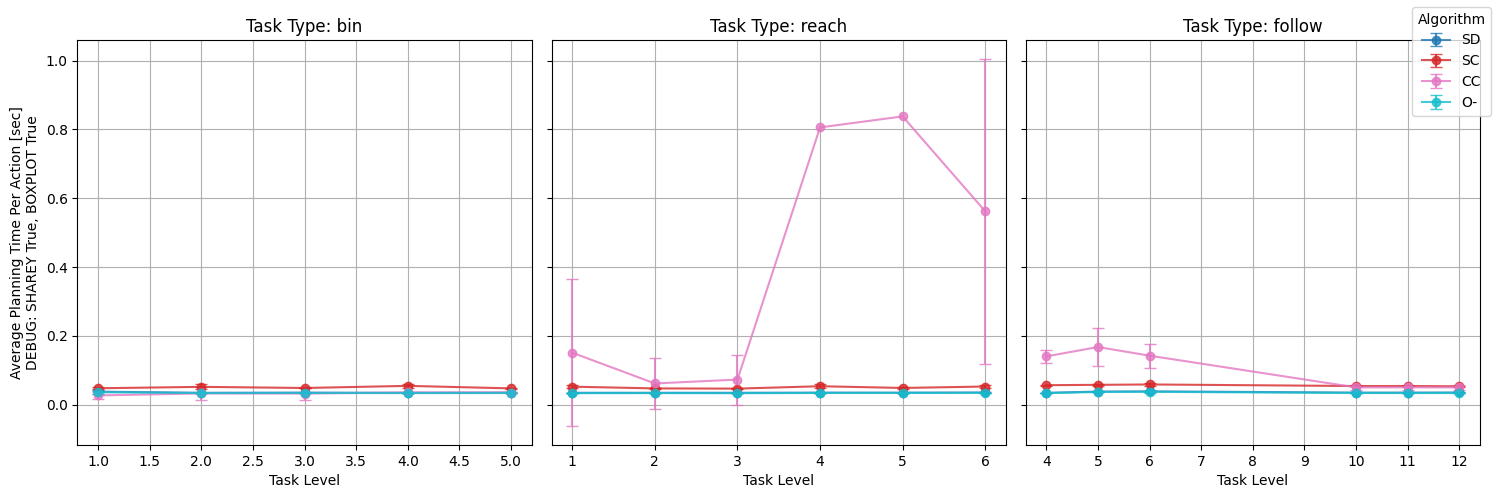

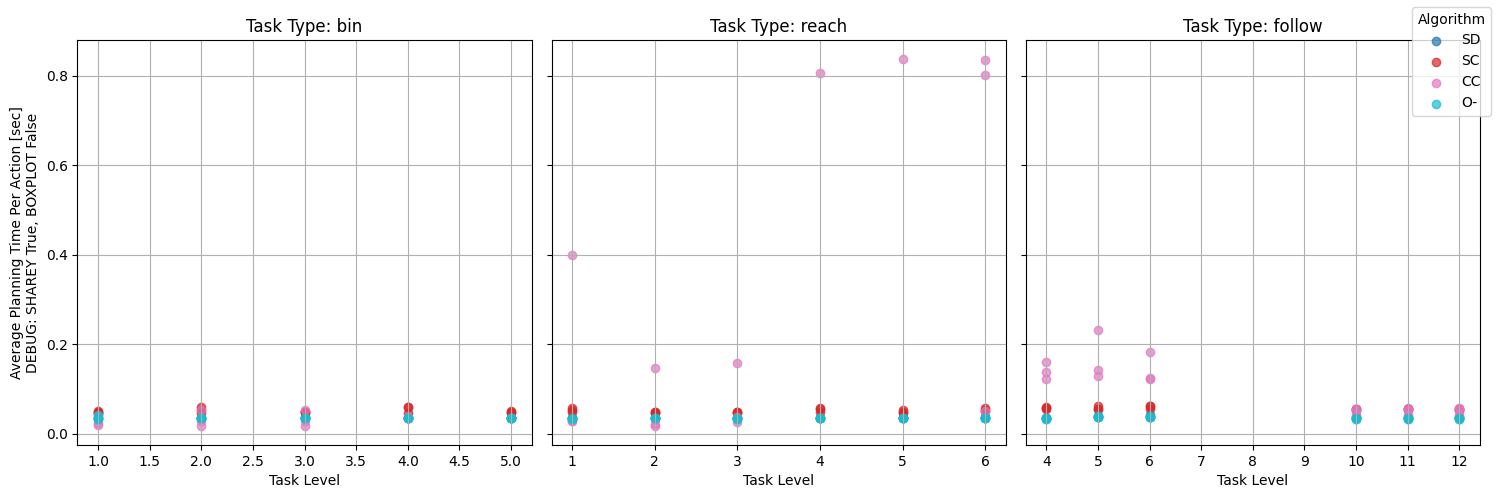

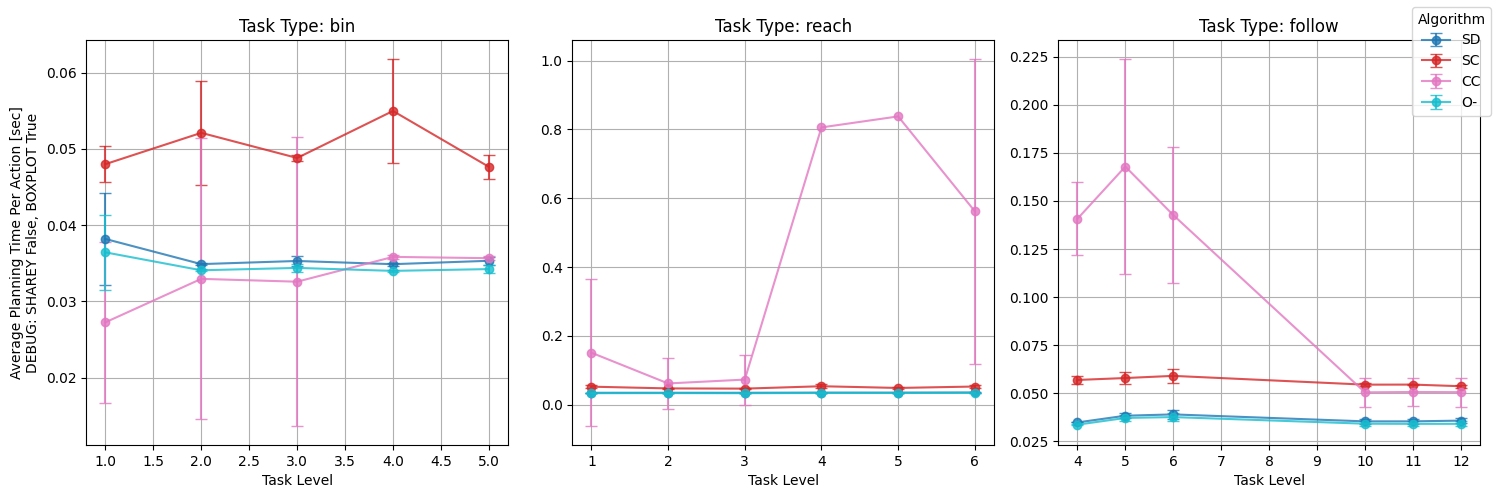

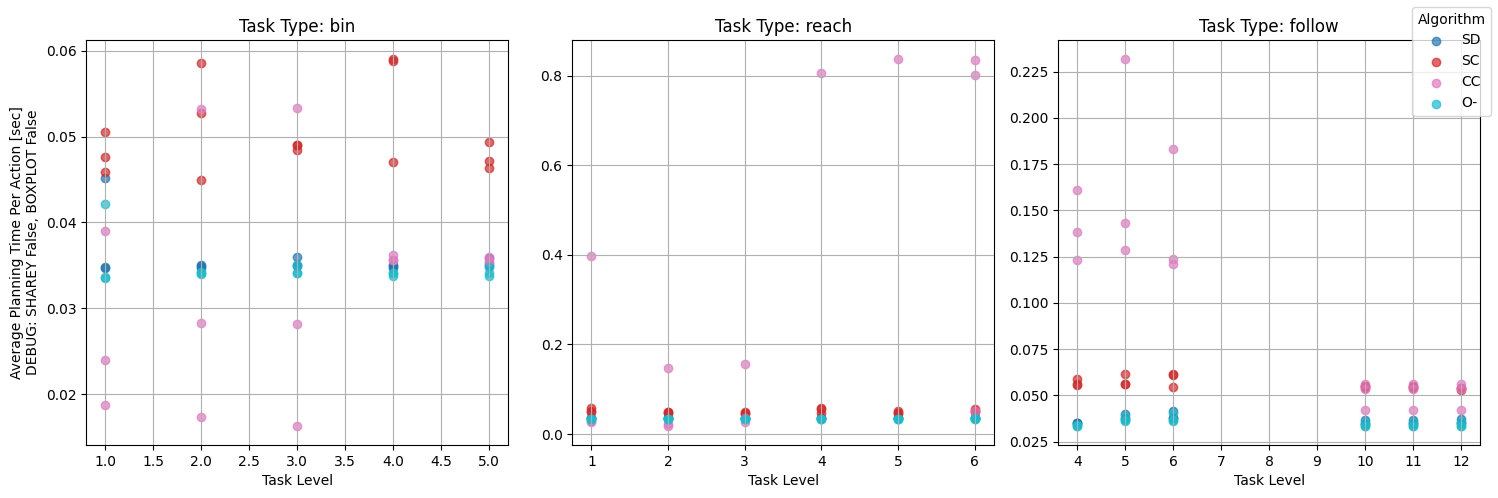

In [330]:
share_y = [True,False]
box_plot = [True,False]
for share_y_i in share_y:
    for box_plot_i in box_plot:
        title = f'Average Planning Time Per Action [sec]\n' + f'DEBUG: SHAREY {share_y_i}, BOXPLOT {box_plot_i}'
        plot_planning_time_per_step(df_planning_time,title, target_col_name='tplanning_moaw',boxplot=box_plot_i,sharey=share_y_i)

In [339]:

def plot_overall_distribution(df, target_label_name='Average Planning Time Per Action [sec]', target_col_name='tplanning_moaw', boxplot=False):
    df_plot = df.copy()

    algs = df_plot["alg"].unique()
    
    fig, ax = plt.subplots(figsize=(8, 6))

    # Assign colors to algorithms
    colors = plt.cm.get_cmap("tab10", len(algs))
    alg_color_map = {alg: colors(i) for i, alg in enumerate(algs)}

    if not boxplot:
        # Scatter plot for each algorithm
        for i, alg in enumerate(algs):
            sdf = df_plot[df_plot["alg"] == alg]
            ax.scatter(
                [i+1] * len(sdf),  # x coordinate = index of algorithm
                sdf[target_col_name],
                color=alg_color_map[alg],
                alpha=0.7,
                label=alg
            )
    else:
        # Boxplot
        data = [df_plot[df_plot["alg"] == alg][target_col_name] for alg in algs]
        ax.boxplot(
            data, labels=algs,
            patch_artist=True,
            boxprops=dict(facecolor="lightgray", alpha=0.5),
            medianprops=dict(color="red", linewidth=2)
        )
        # Color box outlines per algorithm
        for patch, alg in zip(ax.artists, algs):
            patch.set_facecolor(alg_color_map[alg])

    ax.set_xticks(range(1,len(algs)+1))
    ax.set_xticklabels(algs)
    ax.set_xlabel("Algorithm")
    ax.set_ylabel(target_label_name)
    ax.set_title("Distribution of " + target_label_name)
    ax.grid(True, axis="y", linestyle="--", alpha=0.6)

    # Only add legend for scatter mode (boxplot already labeled by xticks)
    if not boxplot:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, title="Algorithm")

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_296371/2380471027.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(algs))
/tmp/ipykernel_296371/2380471027.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


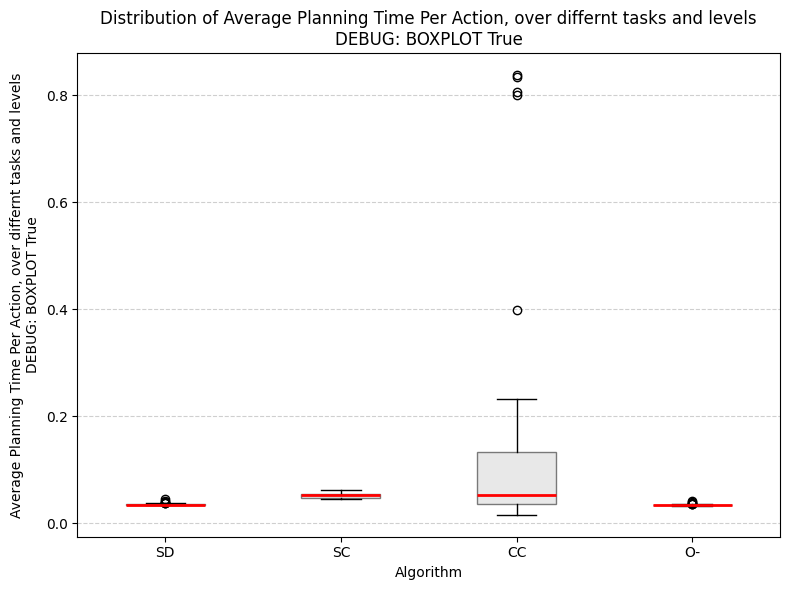

/tmp/ipykernel_296371/2380471027.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(algs))


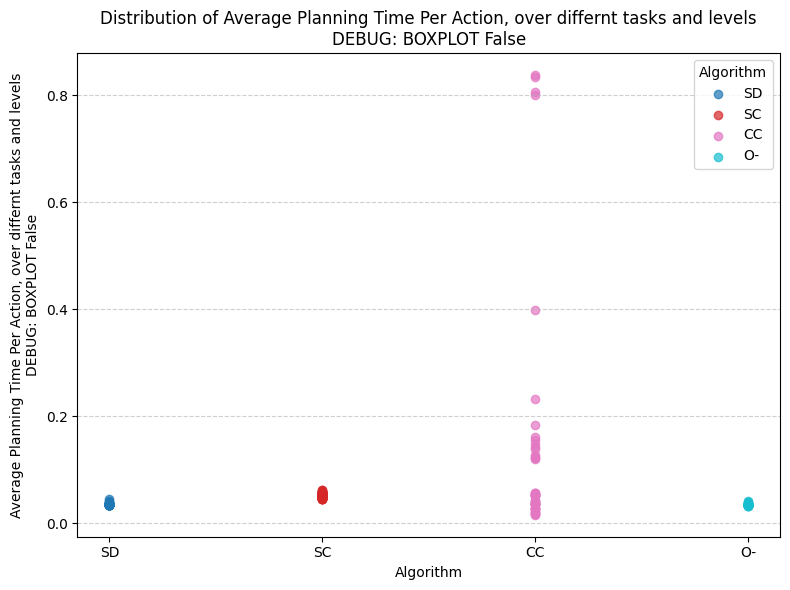

In [340]:
for box_plot_i in box_plot:
    title = f'Average Planning Time Per Action, over differnt tasks and levels\n' + f'DEBUG: BOXPLOT {box_plot_i}'
    plot_overall_distribution(df_planning_time,title, target_col_name='tplanning_moaw',boxplot=box_plot_i)

## Robot Robot collisiosn

In [326]:

all_sims = bin_sims + reach_sims + follow_sims

def check_rrc_rre_for_agent(df):
    
    w_steps_in_rrc = set()
    w_steps_in_rre = set()
    agent_world_col_world_steps = df[df.env_cols == True]['w_step']
    agent_arm_col_world_steps = df[df.arm_cols == True]['w_step']

    for w_step in agent_world_col_world_steps:
        w_steps_in_rrc.add(w_step)
    for w_step in agent_arm_col_world_steps:
        w_steps_in_rre.add(w_step)

    return w_steps_in_rrc, w_steps_in_rre

columns = ['alg', 'n_arms', 'wstep_total', 'task_type', 'task_level', 'rre_n','rrc_n', 'rrc_chance', 'rre_chance']
rows = []
successfull_parsing = []
unsuccessfull_parsing = []
for sim in reach_sims+bin_sims+follow_sims:
    try:
        centralized = sim.is_centralized()
        w_steps_in_rrc = set()
        w_steps_in_rre = set()
        agents_dfs = sim.get_agents_dfs()
        if centralized:
            df = sim.get_agents_dfs()[0]
            n_steps = df.w_step.max()
            rre_n, rrc_n = check_rrc_rre_for_agent(df)
        else:
            # list of dfs one for each agent (arm)
            n_steps = 0    
            for df in agents_dfs:
                rre_n, rrc_n = check_rrc_rre_for_agent(df)
                w_steps_in_rrc = set.union(w_steps_in_rrc, rrc_n)
                w_steps_in_rre = set.union(w_steps_in_rre, rre_n)
                n_steps = max(n_steps, df.w_step.max())
            
        rre_n = len(w_steps_in_rre)
        rrc_n = len(w_steps_in_rrc)
        rre_chance = rre_n / n_steps
        rrc_chance = rrc_n / n_steps
        rows.append([sim.meta_data['alg'], sim.meta_data['n_arms'], n_steps, sim.meta_data['task_type'],sim.meta_data['task_level'], rre_n, rrc_n, rrc_chance, rre_chance])
        successfull_parsing.append(sim)


    except Exception as e:
        unsuccessfull_parsing.append((sim,e))

parsing_summary(successfull_parsing, unsuccessfull_parsing)

df_collisions = pd.DataFrame(rows, columns=columns)
df_collisions



parsing summary:
successfull_parsing: 200
unsuccessfull_parsing: 4
to view errors, see unsuccessfull_parsing[i][1] for error message


,alg,n_arms,wstep_total,task_type,task_level,rre_n,rrc_n,rrc_chance,rre_chance
0,SD,4,500,reach,6,12,469,0.938,0.024
1,CC,4,340,reach,6,0,0,0.000,0.000
2,O-,4,500,reach,6,12,469,0.938,0.024
3,O-,4,500,reach,5,0,472,0.944,0.000
4,SD,4,500,reach,3,0,11,0.022,0.000
...,...,...,...,...,...,...,...,...,...
195,SC,4,500,follow,10,0,0,0.000,0.000
196,CC,4,473,follow,5,0,0,0.000,0.000
197,SC,4,500,follow,5,0,0,0.000,0.000
198,SC,4,500,follow,12,0,0,0.000,0.000


In [327]:
# fig = plt.figure(figsize=(10, 5))
# algs = df_cols.groupby('alg')
# for alg, df in algs:
#     plt.plot(df.n_steps, df.rrc_chance, label=alg)
#     plt.plot(df.n_steps, df.rre_chance, label=alg)
# plt.legend()
# plt.xlabel('Number of Steps')
# plt.ylabel('RRC Chance')
# plt.title('RRC Chance by Number of Steps')
# plt.show()


# plt.show()